In [1]:
import os
import cv2
import numpy as np
# for creating a responsive plot
# %matplotlib widget
# importing required libraries
# from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import torch
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import frontalize
import subprocess
import importlib  
crop_video = importlib.import_module("crop-video")
# %matplotlib inline
import glob
import webinterface
from tqdm import tqdm
%matplotlib inline

In [2]:
import sys
import torch
import torch.nn as nn
import math
from feat.utils import set_torch_device
import torch.nn.functional as F
from copy import deepcopy
import numpy as np
from skimage import draw
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from feat.utils.image_operations import extract_face_from_landmarks

from PIL import Image
from itertools import product
import os 
from torchvision.transforms import Compose, Normalize, Grayscale

import pandas as pd
from tqdm import tqdm
from feat import Detector

from joblib import delayed, Parallel
from torchvision.utils import save_image
from torchvision.io import read_image, read_video
from torch.utils.data import Dataset
from feat.transforms import Rescale
import glob
from skimage.feature import hog
import pickle
from torch.utils.data import DataLoader
from feat.data import (
    Fex,
    ImageDataset,
    VideoDataset,
    _inverse_face_transform,
    _inverse_landmark_transform,
)
import glob
from feat.utils.image_operations import (
    extract_face_from_landmarks,
    extract_face_from_bbox,
    convert_image_to_tensor,
    BBox,
)

In [3]:
detector = Detector(face_model='retinaface',emotion_model='resmasknet', landmark_model="mobilefacenet", au_model='svm')

SAVE_HOG_DIR = 'HOGFeatures/half_faces_mirrored_all/'
# input_file_list = au_df['filepath'].to_list()
mirrored_faces = glob.glob("E:/Datasets/EmotioNet/images/*jpg")

if not os.path.exists(SAVE_HOG_DIR):
    os.makedirs(SAVE_HOG_DIR)

# a list of all path figures

data_loader = DataLoader(
    ImageDataset(
        mirrored_faces,
        output_size=256,
        preserve_aspect_ratio=True,
        padding=True,
    ),
    num_workers=0,
    batch_size=1,
    pin_memory=False,
    shuffle=False,
)

def local_weighted_regression(x0, X, Y, tau):
    x0 = np.r_[1, x0]
    X = np.c_[np.ones(len(X)), X]
     
    xw = X.T * weights_calculate(x0, X, tau)
    theta = np.linalg.pinv(xw @ X) @ xw @ Y

    return x0 @ theta
 
def weights_calculate(x0, X, tau):
    return np.exp(np.sum((X - x0) ** 2, axis=1) / (-2 * (tau **2) ))
def mask_side_cut(image, cut_line, padding=0):
    cut_line_tiled = np.tile(cut_line[:,None], (1,image.shape[1]))
    mask_right = np.zeros((image.shape[0], image.shape[1]))
    
    xx, yy = np.meshgrid(np.arange(image.shape[0]), np.arange(image.shape[1]))
    mask_right[xx <= cut_line_tiled + padding] = 1
    

    mask_left = np.zeros((image.shape[0], image.shape[1]))
    mask_left[xx >= cut_line_tiled - padding] = 1
    
    return mask_right.astype(int), mask_left.astype(int)

def _batch_hog(frames, landmarks):
    """
    Helper function used in batch processing hog features

    Args:
        frames: a batch of frames
        landmarks: a list of list of detected landmarks

    Returns:
        hog_features: a numpy array of hog features for each detected landmark
        landmarks: updated landmarks
    """
    frames = convert_image_to_tensor(frames, img_type="float32")

    hog_features_right = []
    hog_features_left = []
    hog_images_right = []
    hog_images_left = []
    new_landmark_frames = []
    for i, frame_landmark in enumerate(landmarks):
        if len(frame_landmark) != 0:
            new_landmarks_faces = []
            for j in range(len(frame_landmark)):
                convex_hull, new_landmark = extract_face_from_landmarks(
                    frame=frames[i],
                    landmarks=frame_landmark[j],
                    face_size=112,
                )
                
                face_image = np.array(transforms.ToPILImage()(convex_hull[0] / 255.0))
#                 fd, hog_image=hog(
#                         transforms.ToPILImage()(convex_hull[0] / 255.0),
#                         orientations=8,
#                         pixels_per_cell=(8, 8),
#                         cells_per_block=(2, 2),
#                         visualize=True,
#                         channel_axis=-1,
#                     )
                
                
                cut_landmarks=[27,28,29,30,33,51,62,66,57,8]
                cut_line = np.array([local_weighted_regression(y, new_landmark[cut_landmarks,1], new_landmark[cut_landmarks,0], tau=10) for y in range(face_image.shape[1])])

                mask_right, mask_left = mask_side_cut(face_image, cut_line, padding=5)
                
                fd_right, hog_image_right = hog(
                    face_image * mask_right[:,:,None],
                    orientations=8,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    visualize=True,
                    channel_axis=-1,
                )

                fd_left, hog_image_left = hog(
                    face_image * mask_left[:,:,None],
                    orientations=8,
                    pixels_per_cell=(8, 8),
                    cells_per_block=(2, 2),
                    visualize=True,
                    channel_axis=-1,
                )
                
                
                
                
                                
                hog_features_right.append(fd_right)
                hog_features_left.append(fd_left)
                hog_images_right.append(hog_image_right)
                hog_images_left.append(hog_image_left)
                new_landmarks_faces.append(new_landmark)
            
            new_landmark_frames.append(new_landmarks_faces)
        else:
            hog_features_right.append(
                np.zeros((1, 5408))
            )  # LC: Need to confirm this size is fixed.
            hog_features_left.append(
                np.zeros((1, 5408))
            ) 
            new_landmark_frames.append([np.zeros((68, 2))])

    return (hog_features_right, hog_features_left, hog_images_right, hog_images_left, new_landmark_frames)


for cc, batch_data in enumerate(tqdm(data_loader)):
    # Iterate through all the images in dataloader to get the hog feature and landmark feature
#     try:
    faces = detector.detect_faces(
            batch_data["Image"],
            threshold=0.5)

    landmarks = detector.detect_landmarks(
        batch_data["Image"],
        detected_faces=faces)

    hog_features_right, hog_features_left, hog_images_right, hog_images_left, new_landmark_frames = _batch_hog(batch_data["Image"], landmarks)

    for i in range(len(hog_features_right)):
        with open(SAVE_HOG_DIR+batch_data['FileNames'][i].replace("\\","/").split('/')[-1].split('.')[0]+'.pkl', 'wb') as fp:
            pickle.dump((hog_features_right[i],hog_features_left[i], new_landmark_frames[i][0]), fp)
    break
#     except:
#         print('something went wrong with reading the image')
#         with open("error_list_halfface.txt", "a") as f:
#             f.write(batch_data['FileNames'][0].replace("\\","/") + "\n")
#         continue;

  0%|                                                                                        | 0/24598 [00:00<?, ?it/s]


TypeError: Invalid shape (1, 3, 256, 256) for image data

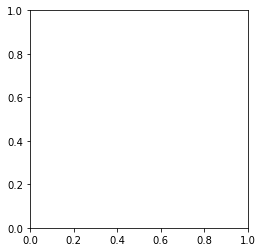

In [6]:
plt.imshow(batch_data["Image"])

In [ ]:
mirrored_faces = glob.glob("mirrored_faces/*.png")

for image in mirrored_faces:
    
    fd, _, points = extract_hog(image, detector=detector)